In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
def relative_schedule(x, total_length, warmup_length):
    """Iteration x"""
    if x < warmup_length:
        y = x / warmup_length
    else:
        y = 1 - ((x - warmup_length) / (total_length - warmup_length))
    
    return y

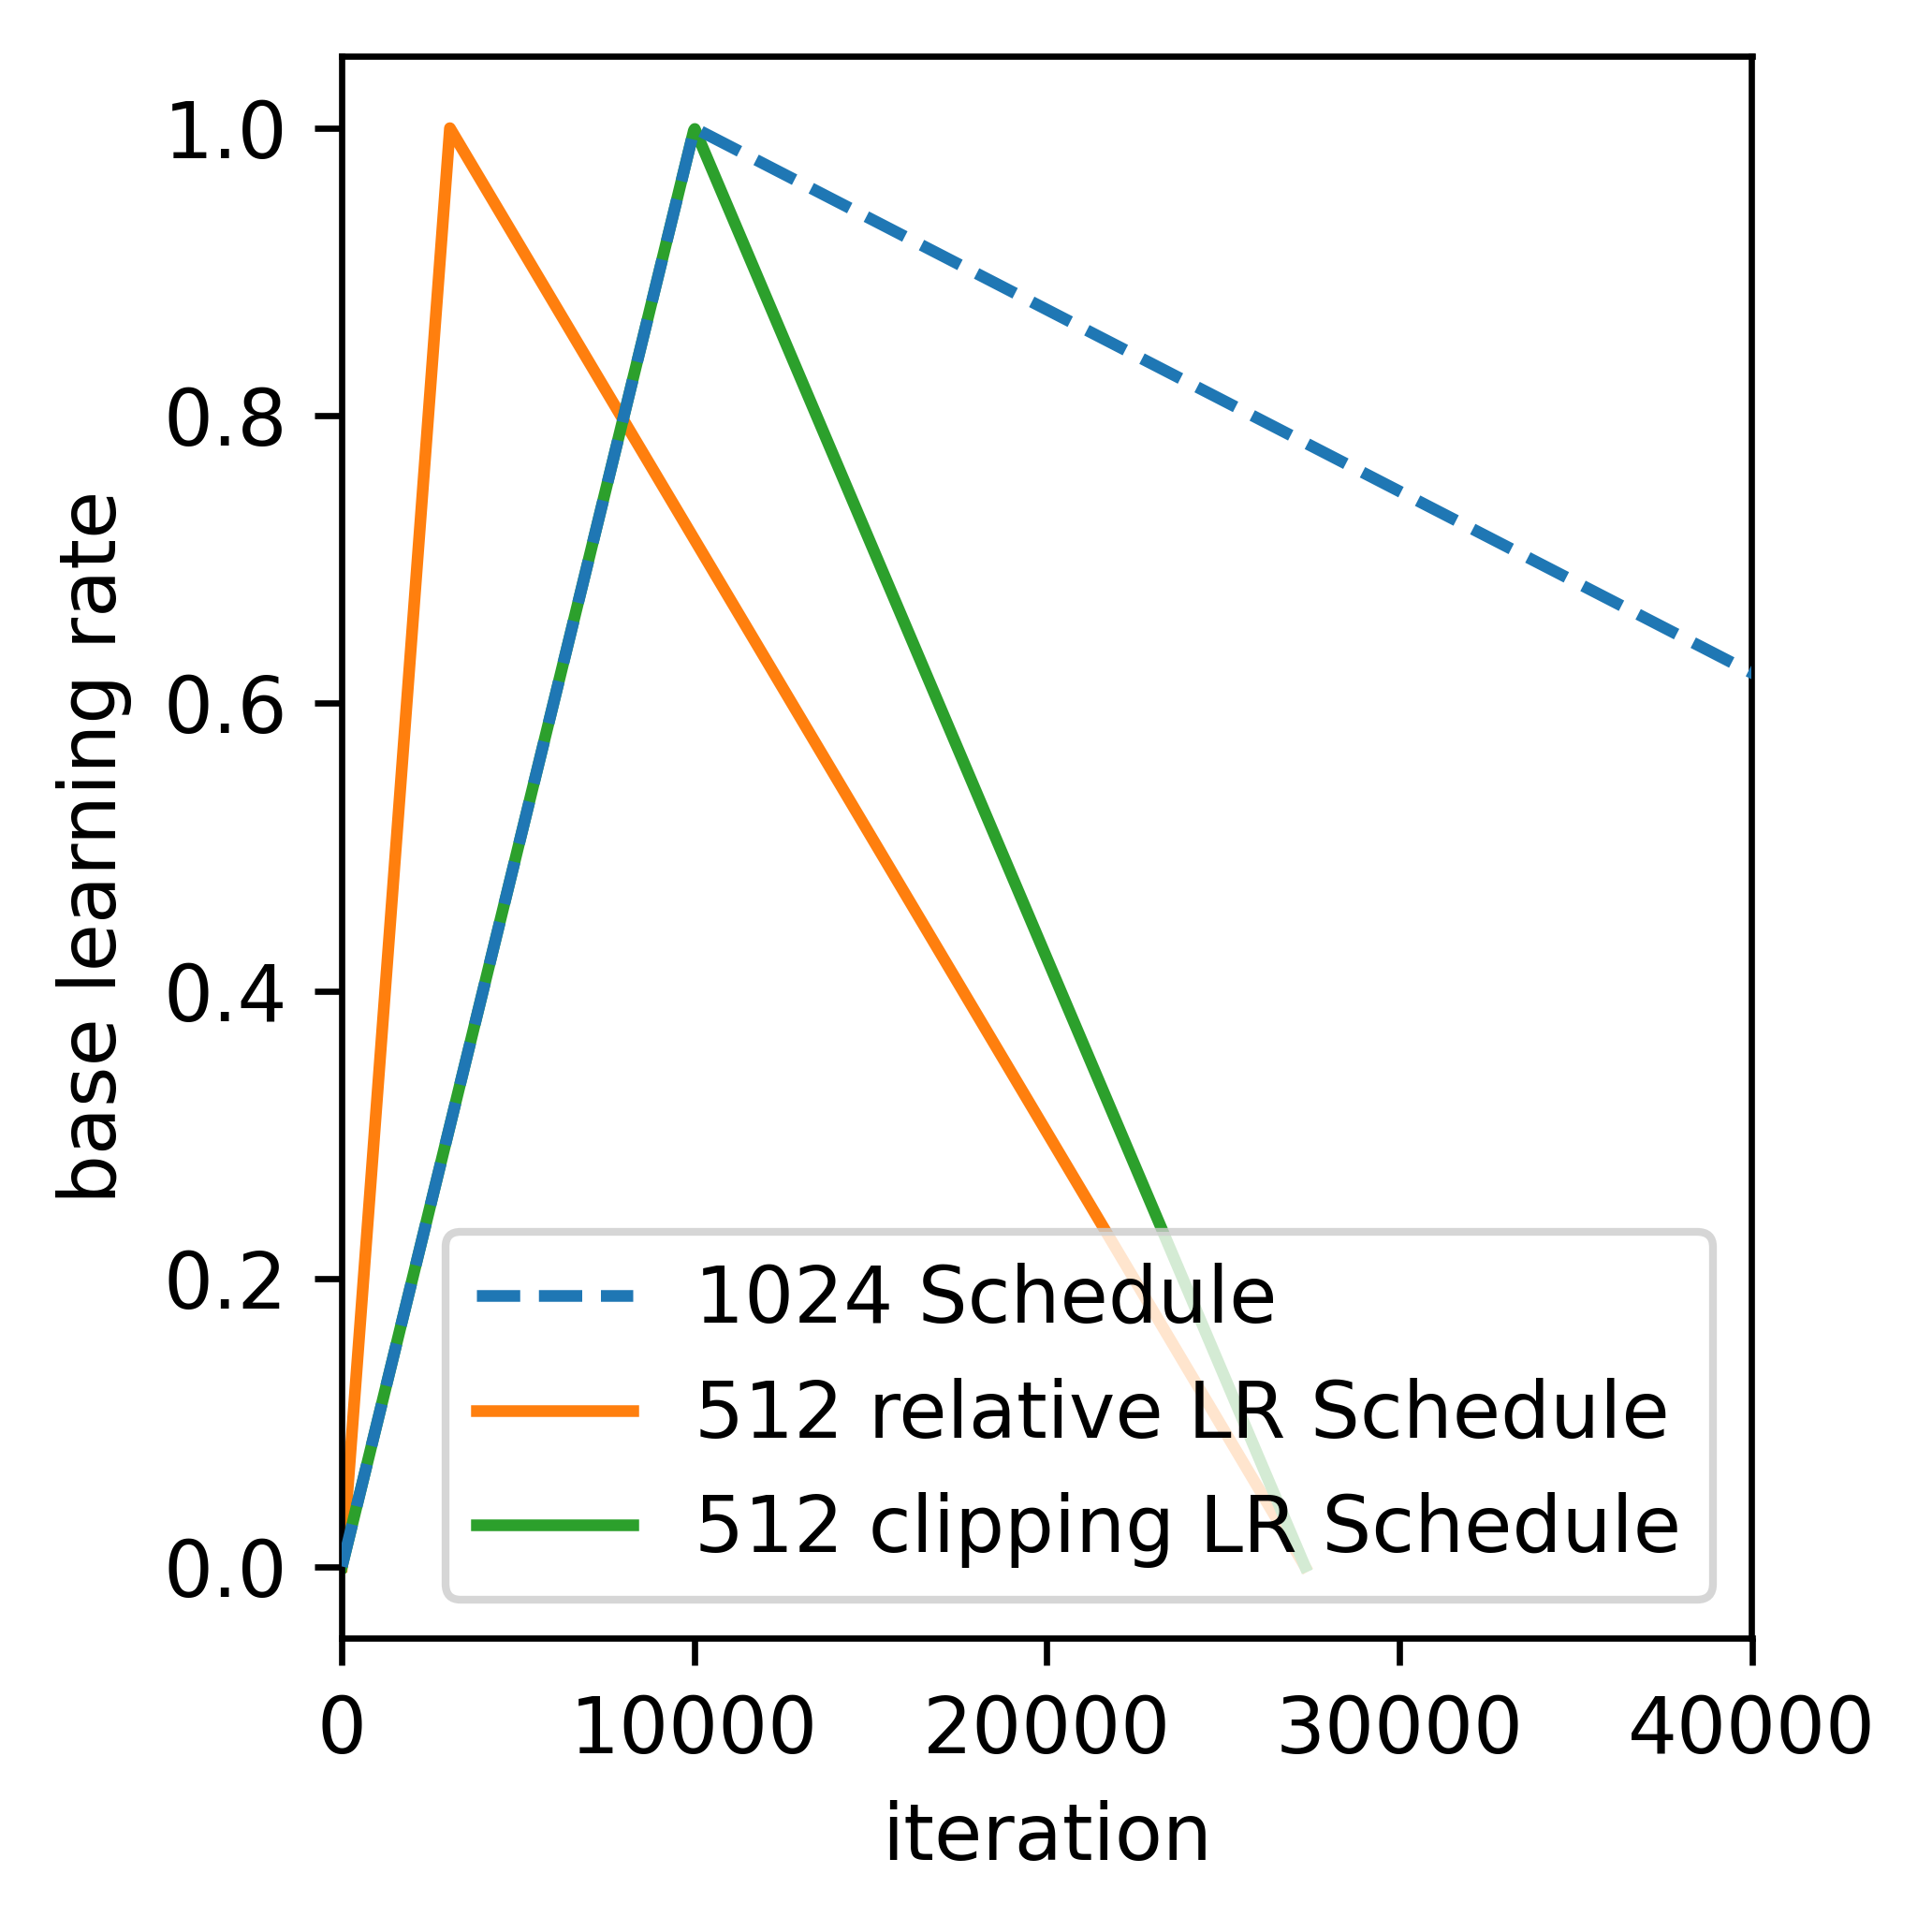

In [32]:
total_length = 89_208
warmup_length = 10_000
xs = np.linspace(0, total_length, 1000)


total_length_smaller_model = 27324
warmup_length_smaller_model = 3062

xs_smaller_model = np.linspace(0, total_length_smaller_model, 1000)

fig, ax = plt.subplots(1, 1, figsize=(3.54, 3.54), dpi=600)

sns.lineplot(
    x=xs,
    y=[relative_schedule(x, total_length, warmup_length) for x in xs],
    ax=ax,
    label='1024 Schedule',
    linestyle='--',
    zorder=3,
)
sns.lineplot(
    x=xs_smaller_model,
    y=[relative_schedule(x, total_length_smaller_model, warmup_length_smaller_model) for x in xs_smaller_model],
    ax=ax,
    label='512 relative LR Schedule',
    zorder=2,
)
sns.lineplot(
    x=xs_smaller_model,
    y=[relative_schedule(x, total_length_smaller_model, warmup_length) for x in xs_smaller_model],
    ax=ax,
    label='512 clipping LR Schedule',
    zorder=2,
)

ax.set_xlim(0, 40_000)

ax.set_xlabel('iteration')
ax.set_ylabel('base learning rate')

plt.tight_layout()
plt.show()